# Day 3 — Training Dynamics & Optimization

## Note 3.1 — Optimizers and the Learning Rate

### Learning goal

On Day 2, you wrote a training loop containing:

```python
optimizer.zero_grad()
loss = loss_fn(model(xb), yb)
loss.backward()
optimizer.step()
```

The first three lines tell PyTorch how to calculate the gradient. The last line tells PyTorch **how to use that gradient to change the model's parameters**.

Today we open up that last line.

The two main questions are:

1. **Which optimizer should we use?**
2. **How large should each parameter update be?**

The second question is controlled mainly by the **learning rate**.

By the end of this note, you should be able to look at a training curve and make a reasonable diagnosis:

```text
curve is barely moving
        ↓
learning rate may be too small

curve improves quickly then bounces
        ↓
learning rate may be slightly too large

curve explodes or collapses
        ↓
learning rate may be far too large
```

The goal is not to memorise optimizer names. The goal is to understand what the optimizer and learning rate are doing to the model's parameters.

### Objectives

You will:

- explain what one parameter update means for SGD, momentum, Adam, and AdamW;
- understand why the same numerical learning rate can behave very differently with different optimizers;
- understand what Adam stores internally and why that costs memory;
- understand what **weight decay** is and why AdamW separates it from Adam's adaptive update;
- compare optimizers fairly;
- recognise the main learning-rate failure patterns;
- use an **LR range test** to find a useful starting range;
- understand when a learning-rate schedule is useful and when it adds unnecessary complexity.

### Dataset

We use the **UCI Bank Marketing** dataset, the same dataset used in Day 2.

Keeping the dataset, preprocessing, model architecture, and evaluation procedure the same is deliberate. It gives us a known reference point so that today's experiments mainly measure the effect of optimization choices.

The dataset contains 45,211 rows. After preprocessing, the baseline MLP has 5,377 trainable parameters.

We again remove `duration`.

`duration` tells us how long the sales call lasted, but that value is only known after the call has happened. If the goal is to predict the outcome before that outcome is known, using `duration` would give the model information that would not be available at prediction time. This is **target leakage**.

### The mental model for this note

A neural network has parameters:

```text
weights and biases
       ↓
parameters
       ↓
gradient tells us which direction to move
       ↓
optimizer decides how to turn that gradient into an update
       ↓
learning rate controls the scale of that update
       ↓
new parameters
```

So:

> **Gradient = direction of improvement.**  
> **Optimizer = rule for turning gradients into updates.**  
> **Learning rate = main control over the size of those updates.**

### Table of contents

1. The line you trusted
2. Watching SGD zig-zag, and giving it momentum
3. Adam: one learning rate per parameter
4. AdamW and weight decay
5. Four optimizers, one model, one plot
6. Five learning rates, five signatures
7. Finding a learning rate in one run
8. Schedules
9. What actually moved the needle

### Environment and setup

Everything in this notebook is intentionally small enough to run on a CPU.

The purpose is not to train a large model. The purpose is to **see optimization behaviour clearly**.

A GPU is therefore not required.

The notebook also fixes the random seed so that the experiments are as reproducible as possible. A seed does not guarantee identical results on every machine, but it removes a major source of unnecessary randomness.

### What the setup code is doing

The setup imports the libraries used throughout the notebook and fixes the random seeds.

The device is detected first, but then the notebook deliberately forces CPU execution so that timing comparisons are more consistent across machines.

The seed is used for:

- model initialisation;
- NumPy randomness;
- DataLoader shuffling.

This means that when we intentionally change one experimental variable, we are less likely to be measuring an unrelated random difference.


In [1]:
# Pinned versions this notebook was built and executed against.
# torch 2.14.0  |  scikit-learn 1.8.0  |  numpy 2.4.4  |  pandas 3.0.2  |  matplotlib 3.10.8

import sys, time, io, zipfile, urllib.request, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# --- environment detection -------------------------------------------------
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"python       {sys.version.split()[0]}")
print(f"torch        {torch.__version__}")
print(f"device       {DEVICE}")
print(f"threads      {torch.get_num_threads()}")

# Everything in this notebook is small enough that CPU is fine.
# We stay on CPU deliberately so timings are comparable across machines.
DEVICE = torch.device("cpu")
print(f"using        {DEVICE}  (forced, for comparable timings)")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


python       3.13.9
torch        2.14.0
device       mps
threads      5
using        cpu  (forced, for comparable timings)


### Load the data

The code downloads the Bank Marketing dataset once and stores it locally.

`pd.read_csv(...)` turns the CSV file into a pandas DataFrame.

The important output to notice is the shape:

```text
(rows, columns)
```

Each row represents one marketing example. Each column represents one feature or the target.

In [2]:
# --- data ------------------------------------------------------------------
# Downloads once (~1 MB) and caches locally. No auth key needed.

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
CSV = os.path.join(DATA_DIR, "bank-full.csv")

if not os.path.exists(CSV):
    url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
    print("downloading Bank Marketing ...")
    raw = urllib.request.urlopen(url, timeout=120).read()
    outer = zipfile.ZipFile(io.BytesIO(raw))
    inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
    with open(CSV, "wb") as f:
        f.write(inner.read("bank-full.csv"))
    print("saved to", CSV)

df = pd.read_csv(CSV, sep=";")
print("raw shape:", df.shape)
df.head(3)


raw shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


### Preprocess the data

The preprocessing is intentionally the same as Day 2.

The target is converted from:

```text
"yes" / "no"
```

into:

```text
1 / 0
```

Numerical features are standardised.

Categorical features are one-hot encoded.

Most importantly, the preprocessing object is **fit only on the training split** and then used to transform validation data.

That prevents validation information from influencing the preprocessing rules.


In [3]:
# --- preprocessing: identical to Day 2, Note 2.3 ---------------------------
y_all = (df["y"] == "yes").astype(np.float32).values
X_all = df.drop(columns=["y", "duration"])      # duration dropped: post-outcome leakage

In [4]:
y_all

array([0., 0., 0., ..., 1., 0., 0.], shape=(45211,), dtype=float32)

In [5]:
num_cols = X_all.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X_all.columns if c not in num_cols]

X_tr_raw, X_va_raw, y_tr, y_va = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

In [6]:
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
A_tr = pre.fit_transform(X_tr_raw).astype(np.float32)   # fit on TRAIN only
A_va = pre.transform(X_va_raw).astype(np.float32)

N_FEATURES = A_tr.shape[1]
print(f"numeric columns      {len(num_cols)}  {num_cols}")
print(f"categorical columns  {len(cat_cols)}")
print(f"train / val rows     {A_tr.shape[0]} / {A_va.shape[0]}")
print(f"feature dimension    {N_FEATURES}")
print(f"positive rate        train {y_tr.mean():.4f}   val {y_va.mean():.4f}")
print(f"majority-class acc   {max(y_va.mean(), 1 - y_va.mean()):.4f}")

X_tr = torch.tensor(A_tr); Y_tr = torch.tensor(y_tr).unsqueeze(1)
X_va = torch.tensor(A_va); Y_va = torch.tensor(y_va).unsqueeze(1)

numeric columns      6  ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
categorical columns  9
train / val rows     36168 / 9043
feature dimension    50
positive rate        train 0.1170   val 0.1170
majority-class acc   0.8830


### A note on reproducibility

The numbers in this notebook should be close to the Day 2 results, but they do not have to match every decimal place.

A train/validation split depends on randomness. A different split means a slightly different validation set, which can produce a slightly different AUC.

So when we say the Day 2 reference is around **0.79–0.80 ROC-AUC**, we are describing the approximate performance range rather than claiming that one exact decimal value is universal.

This matters because optimization experiments should not be treated as exact physical constants.

A useful principle is:

> **One run gives you an observation. Repeated runs tell you how stable that observation is.**

Note 3.2 will investigate this more carefully.


In [7]:
# --- the baseline model and a reusable training function -------------------
# 50 -> 64 -> 32 -> 1, exactly the Day 2 architecture.

In [8]:
def make_model(n_features=N_FEATURES, seed=SEED):
    torch.manual_seed(seed)
    return nn.Sequential(
        nn.Linear(n_features, 64), nn.ReLU(),
        nn.Linear(64, 32), nn.ReLU(),
        nn.Linear(32, 1),
    )

_m = make_model()
print("architecture:", " -> ".join(str(l.out_features) for l in _m if isinstance(l, nn.Linear)))
print("parameters:  ", sum(p.numel() for p in _m.parameters()))

loss_fn = nn.BCEWithLogitsLoss()

architecture: 64 -> 32 -> 1
parameters:   5377


In [9]:
def train(optimizer_name, lr, epochs=15, batch_size=256, seed=SEED,
          weight_decay=0.0, scheduler=None, momentum=0.9, verbose=False):
    """Train the baseline MLP and return per-epoch history."""
    model = make_model(seed=seed)
    g = torch.Generator().manual_seed(seed)

    if optimizer_name == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "momentum":
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    elif optimizer_name == "adam":
        opt = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "adamw":
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(optimizer_name)

    sched = None
    if scheduler == "step":
        sched = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.1)
    elif scheduler == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr),
        batch_size=batch_size, shuffle=True, generator=g)

    hist = []
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        running, n = 0.0, 0
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            running += loss.item() * len(xb); n += len(xb)
        if sched is not None:
            sched.step()

        model.eval()
        with torch.no_grad():
            logits = model(X_va)
            val_loss = loss_fn(logits, Y_va).item()
            probs = torch.sigmoid(logits).numpy().ravel()
        auc = roc_auc_score(y_va, probs) if np.isfinite(probs).all() else float("nan")

        hist.append(dict(epoch=ep, train_loss=running / n, val_loss=val_loss,
                         val_auc=auc, lr=opt.param_groups[0]["lr"]))
        if verbose:
            print(f"  ep{ep:3d}  train {running/n:.4f}  val {val_loss:.4f}  auc {auc:.4f}")

    return dict(history=hist, seconds=time.time() - t0, model=model)

print("\ntraining helper ready.")


training helper ready.


## 1. The line you trusted

In Day 2, the training loop contained:

```python
optimizer.zero_grad()
loss = loss_fn(model(xb), yb)
loss.backward()
optimizer.step()
```

Let's separate the jobs:

**1. `zero_grad()`**

PyTorch stores gradients inside each parameter's `.grad` attribute.

Before calculating a new gradient, we normally clear the old one.

**2. `loss.backward()`**

Backpropagation calculates how the loss changes with respect to each parameter.

In simplified notation:

```text
loss
  ↓
how much should each parameter change?
  ↓
gradient for each parameter
```

For a parameter `p`, PyTorch stores this result in:

```python
p.grad
```

**3. `optimizer.step()`**

This is the part we are studying today.

The optimizer takes the gradients and decides how to change the parameters.

For plain **stochastic gradient descent (SGD)**, the rule is:

$$p \leftarrow p - \eta \cdot \nabla_p L$$

where:

- `p` = the current parameter;
- `L` = the loss;
- `∇p L` = the gradient of the loss with respect to `p`;
- `η` (eta) = the learning rate.

Why do we subtract the gradient?

Because the gradient points in the direction in which the loss increases fastest. Moving in the opposite direction therefore tends to reduce the loss.

For example, if:

```text
gradient = +0.01
learning rate = 0.1
```

then:

```text
parameter change = -0.1 × 0.01
                 = -0.001
```

So the parameter moves down by `0.001`.

This is the simplest optimizer possible.

The experiment below replaces `optimizer.step()` with this arithmetic so we can verify that PyTorch's SGD is doing exactly what the equation says.

In [10]:
# Take one real batch and one real model, and step it two ways.
xb, yb = X_tr[:256], Y_tr[:256]
LR = 0.1

In [11]:
# --- way 1: torch's SGD ---
m1 = make_model()
opt1 = torch.optim.SGD(m1.parameters(), lr=LR)
opt1.zero_grad()
loss_fn(m1(xb), yb).backward()
opt1.step()

In [12]:
# --- way 2: the arithmetic, by hand ---
m2 = make_model()                      # same seed => same starting weights
m2.zero_grad()
loss_fn(m2(xb), yb).backward()
with torch.no_grad():
    for p in m2.parameters():
        p -= LR * p.grad               # <-- the whole of SGD

In [13]:
# --- compare ---
diffs = [ (a - b).abs().max().item() for a, b in zip(m1.parameters(), m2.parameters()) ]
print("max |torch_SGD - hand_written| per tensor:", [f"{d:.2e}" for d in diffs])
print("largest difference anywhere:", f"{max(diffs):.2e}")

max |torch_SGD - hand_written| per tensor: ['7.45e-09', '0.00e+00', '7.45e-09', '3.73e-09', '1.16e-10', '0.00e+00']
largest difference anywhere: 7.45e-09


In [14]:
diffs

[7.450580596923828e-09,
 0.0,
 7.450580596923828e-09,
 3.725290298461914e-09,
 1.1641532182693481e-10,
 0.0]

The two implementations agree up to tiny floating-point rounding differences.

That gives us a precise interpretation of the learning rate.

> **The learning rate is not just a vague "speed" setting. It is the factor that scales the gradient when SGD turns a gradient into a parameter update.**

For example:

```text
gradient ≈ 0.01
learning rate = 0.1

update ≈ 0.1 × 0.01
       = 0.001
```

The actual update therefore depends on **both** the learning rate and the size of the gradient.

This explains why a learning rate that works on one problem may be terrible on another.

The four update rules (Other optimers) in this note can be thought of as modifications of the same basic idea:

```text
SGD
→ use the raw gradient

Momentum
→ smooth the gradient using recent history

Adam
→ smooth the gradient AND scale it according to each parameter's typical gradient size

AdamW
→ do Adam's adaptive update, while applying weight decay separately
```

So the training loop stays almost the same. What changes is the rule used by `optimizer.step()`.


### Check your understanding

Suppose every input feature in the dataset were multiplied by `2`.

Would the same learning rate necessarily behave the same way?

Probably not.

Changing the scale of the inputs changes the scale of the activations and, consequently, can change the scale of the gradients.

That means preprocessing can affect optimization.

This is one reason `StandardScaler` is not merely cosmetic data cleaning. By putting numerical features on more comparable scales, it can make the optimization problem easier for a gradient-based optimizer to navigate.

Think of it this way:

> **The model is learning in parameter space, but the scale of the inputs influences the shape and scale of the gradients that guide that learning.**

<a id="s2"></a>
## 2. Watching SGD zig-zag, and giving it momentum

It is easier to understand an optimizer on a simple surface than inside a 5,377-parameter neural network.

Imagine a long, narrow valley:

```text
        steep
          ↕
       \     /
        \   /
         \_/
          →
       shallow
```

The bottom of the valley contains the minimum.

The important detail is that the surface is:

- **very steep in one direction**;
- **much flatter in another direction**.

This can happen when different parameters have very different scales.

### What does the gradient do?

The gradient points in the direction of **steepest increase**.

Gradient descent moves in the opposite direction, so it always tries to move downhill.

The problem is that in a narrow valley, the downhill direction can point strongly across the valley rather than along the valley floor.

So the optimizer can do this:

```text
left wall → right wall → left wall → right wall
```

while making only slow progress toward the actual minimum.

This is the **zig-zag problem**.

Momentum is designed to reduce that behaviour.

In [15]:
# A 2-D quadratic bowl, stretched 20:1. f(x, y) = 0.05*x^2 + y^2
def f(p):     return 0.05 * p[0]**2 + 1.0 * p[1]**2
def grad(p):  return np.array([0.10 * p[0], 2.0 * p[1]])

def descend(lr, beta=0.0, steps=40, start=(-9.0, 2.5)):
    """beta=0 is plain SGD; beta>0 adds classical momentum."""
    p = np.array(start, dtype=float)
    v = np.zeros(2)
    path = [p.copy()]
    for _ in range(steps):
        g = grad(p)
        v = beta * v + g          # velocity: a running blend of past gradients
        p = p - lr * v
        path.append(p.copy())
    return np.array(path)

In [16]:
path_sgd = descend(lr=0.85, beta=0.0)
path_mom = descend(lr=0.85, beta=0.30)

print(f"after 40 steps, plain SGD    : x={path_sgd[-1][0]:+.4f}  y={path_sgd[-1][1]:+.4f}  loss={f(path_sgd[-1]):.5f}")
print(f"after 40 steps, momentum 0.30: x={path_mom[-1][0]:+.4f}  y={path_mom[-1][1]:+.4f}  loss={f(path_mom[-1]):.5f}")
print()
print(f"per-step multiplier in the steep y direction: {1-0.85*2:+.2f}")
print("  negative => the sign of y flips every step => visible zig-zag")

after 40 steps, plain SGD    : x=-0.2577  y=+0.0000  loss=0.00332
after 40 steps, momentum 0.30: x=-0.0377  y=-0.0000  loss=0.00007

per-step multiplier in the steep y direction: -0.70
  negative => the sign of y flips every step => visible zig-zag


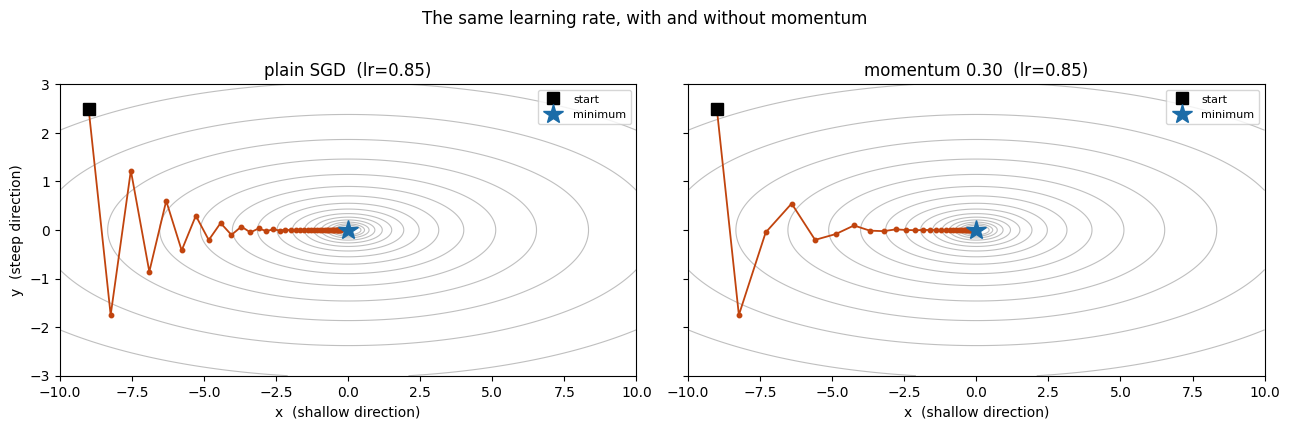

In [17]:
xs = np.linspace(-10, 10, 300); ys = np.linspace(-3, 3, 300)
XX, YY = np.meshgrid(xs, ys); ZZ = 0.05 * XX**2 + YY**2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True, sharey=True)
for ax, path, title in [(axes[0], path_sgd, "plain SGD  (lr=0.85)"),
                        (axes[1], path_mom, "momentum 0.30  (lr=0.85)")]:
    ax.contour(XX, YY, ZZ, levels=np.logspace(-2, 1.6, 18), colors="0.75", linewidths=0.8)
    ax.plot(path[:, 0], path[:, 1], "o-", ms=3.2, lw=1.3, color="#c1440e")
    ax.plot(*path[0], "s", ms=8, color="black", label="start")
    ax.plot(0, 0, "*", ms=15, color="#1b6ca8", label="minimum")
    ax.set_title(title); ax.set_xlabel("x  (shallow direction)")
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("y  (steep direction)")
plt.suptitle("The same learning rate, with and without momentum", y=1.01)
plt.tight_layout(); plt.show()


The left panel shows the problem with plain SGD.

The optimizer repeatedly crosses the valley in the steep `y` direction while making much slower progress along the shallow `x` direction.

Momentum adds memory.

Instead of using only the current gradient, it keeps a **velocity** that contains information from recent gradients:


$$v \leftarrow \beta v + \nabla_p L$$

and then updates the parameter using that velocity:

$$p \leftarrow p - \eta v$$

Here:

- `v` = accumulated direction of recent gradients;
- `β` = how much of the previous velocity we keep;
- `η` = learning rate.

### Why does this reduce zig-zagging?

In the steep direction, the gradient may keep changing sign:

```text
step 1 → right
step 2 → left
step 3 → right
step 4 → left
```

Those opposing directions partially cancel inside the velocity.

Along the shallow direction, the gradient may keep pointing in roughly the same direction:

```text
→ → → → →
```

Those contributions accumulate.

So momentum has a useful intuition:

> **It reduces movement that keeps changing direction and reinforces movement that remains consistently useful.**

This is why momentum is sometimes described as a kind of smoothing or low-pass filtering of the gradient.

With `β = 0.9`, the optimizer keeps a large amount of the previous velocity. A rough intuition is that it incorporates information from around the previous `1/(1-β) = 10` steps, although this is not a literal ten-step window.


### Why the demonstration uses `beta=0.30`

The demonstration deliberately uses a smaller momentum value than the common `0.9`.

The learning rate in this toy example is already large enough to be close to the stability boundary.

The multiplier in the steep direction is:

```text
1 - learning_rate × 2
= 1 - 0.85 × 2
= -0.70
```

The negative sign means the parameter changes sides on each step. The magnitude `0.70` means the oscillation is still large.

Momentum can make the effective update larger because it accumulates gradients.

So:

> **Learning rate and momentum are not independent knobs.**

Increasing momentum can make an otherwise stable learning rate unstable.

This does not mean `beta=0.9` is bad. It means the learning rate and momentum need to be considered together.

A practical intuition is:

```text
more momentum
    ↓
more accumulated movement
    ↓
you may need a smaller learning rate
```

<a id="s3"></a>
## 3. Adam: adapting the step for each parameter

Momentum remembers recent gradients.

Adam goes one step further: it also keeps track of the **typical size of the gradients for each parameter**.

Why is that useful?

Different parameters in the same neural network can receive gradients with very different magnitudes.

For example, imagine two input features:

```text
age
job=student
```

`age` is a dense numerical feature. Many examples contain a meaningful age value.

`job=student` is a one-hot feature. It is `1` only for examples belonging to that category and `0` otherwise.

The corresponding weights can therefore experience very different gradient patterns.

One global learning rate may not be ideal for both.

### Adam keeps two pieces of information

For every parameter, Adam maintains:

**1. First moment (`m`)**

A running average of the gradient.

This is closely related to momentum.

**2. Second moment (`v`)**

A running average of the **squared gradient**.

Because the gradient is squared, `v` tells us roughly how large the gradient has typically been, without positive and negative values cancelling each other.

Adam then uses approximately:

$$m / (\sqrt{v} + \epsilon)$$

as the direction and scale of the adaptive update.

The important intuition is:

> **If a parameter normally receives very large gradients, Adam scales its update down. If it receives small gradients, Adam scales its update up.**

The global learning rate then controls the overall size of these already-normalised updates.

That is why Adam's learning rate behaves differently from plain SGD's learning rate.

In [18]:
# Train briefly with Adam, then open the optimizer's state and look inside.
m = make_model()
opt = torch.optim.Adam(m.parameters(), lr=1e-3)
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_tr, Y_tr), batch_size=256, shuffle=True,
    generator=torch.Generator().manual_seed(SEED))

m.train()
for i, (xb, yb) in enumerate(loader):
    opt.zero_grad(); loss_fn(m(xb), yb).backward(); opt.step()
    if i == 199: break            # 200 steps is plenty to populate the buffers

first_layer_w = list(m.parameters())[0]          # shape (64, 50)
state = opt.state[first_layer_w]
print("Adam keeps these per parameter tensor:", list(state.keys()))
print("step count:", int(state["step"]))
print("exp_avg    (m, 1st moment) shape:", tuple(state["exp_avg"].shape))
print("exp_avg_sq (v, 2nd moment) shape:", tuple(state["exp_avg_sq"].shape))
print()
print("So Adam stores 2 extra floats per parameter.")
n_params = sum(p.numel() for p in m.parameters())
print(f"model parameters      {n_params:,}")
print(f"Adam optimizer state  {2*n_params:,} floats  ({2*n_params*4/1024:.1f} KB at fp32)")


Adam keeps these per parameter tensor: ['step', 'exp_avg', 'exp_avg_sq']


step count: 142
exp_avg    (m, 1st moment) shape: (64, 50)
exp_avg_sq (v, 2nd moment) shape: (64, 50)

So Adam stores 2 extra floats per parameter.
model parameters      5,377
Adam optimizer state  10,754 floats  (42.0 KB at fp32)


### Adam's memory cost

Adam stores two extra values for every trainable parameter:

```text
parameter
   ↓
first-moment value (m)
second-moment value (v)
```

So if the model has `N` parameters, Adam needs roughly:

```text
N parameter values
+ N first-moment values
+ N second-moment values
```

That is about **3× the parameter storage** before considering gradients and other training memory.

For a 5,377-parameter model, this is tiny.

For a multi-billion-parameter model, it becomes significant.

This is one reason memory-efficient fine-tuning methods such as LoRA become important for large models.

The key lesson for this note is simply:

> **Adam is more adaptive, but that adaptiveness has a memory cost.**


In [19]:
# How much does each parameter actually move, per step, under each rule?
sq = state["exp_avg_sq"]
typical_grad = sq.sqrt()                       # RMS gradient magnitude, per parameter

print("RMS gradient magnitude across the 3,200 weights of layer 1:")
print(f"   min    {typical_grad.min().item():.3e}")
print(f"   median {typical_grad.median().item():.3e}")
print(f"   max    {typical_grad.max().item():.3e}")
print(f"   ratio max/min: {(typical_grad.max()/typical_grad.min()).item():,.0f}x")
print()
print("Under SGD, step size is proportional to the gradient, so those")
print("parameters move at wildly different rates with one global lr.")
print()
print("Under Adam, the step is m/(sqrt(v)+eps), which is ~O(1) regardless,")
print("then scaled by lr. So lr sets the step size DIRECTLY in weight units.")
print()
print("Consequence: Adam's lr is roughly 'how far should any weight move per step',")
print("which is a small number (1e-3). SGD's lr must compensate for gradient")
print("magnitude, so it is typically 10-100x larger. Section 6 measures this.")


RMS gradient magnitude across the 3,200 weights of layer 1:
   min    7.017e-07
   median 2.103e-04
   max    3.669e-03
   ratio max/min: 5,229x

Under SGD, step size is proportional to the gradient, so those
parameters move at wildly different rates with one global lr.

Under Adam, the step is m/(sqrt(v)+eps), which is ~O(1) regardless,
then scaled by lr. So lr sets the step size DIRECTLY in weight units.

Consequence: Adam's lr is roughly 'how far should any weight move per step',
which is a small number (1e-3). SGD's lr must compensate for gradient
magnitude, so it is typically 10-100x larger. Section 6 measures this.


The experiment shows that different parameters can have very different typical gradient magnitudes.

This is exactly the situation Adam was designed to handle.

Under plain SGD:

```text
update = learning_rate × raw_gradient
```

So if one parameter has a gradient 100 times larger than another, its update will also tend to be much larger.

Adam normalises the gradient using its running estimate of gradient magnitude:

```text
adaptive update ≈ m / (sqrt(v) + eps)
```

So the learning rate now acts more directly as a control over the size of the parameter movement.

This is why the useful numerical learning rates are often very different:

```text
SGD on this problem → much larger lr
Adam on this problem → much smaller lr
```

Do not interpret that as a universal conversion such as "Adam is always exactly 100× smaller."

The numbers depend on the problem and the optimizer state.

### What is `eps`?

Adam divides by:

```text
sqrt(v) + eps
```

`eps` is a very small number, commonly `1e-8`.

Its job is to prevent division by zero or by an extremely tiny number.

If a parameter has received zero gradient for many steps, `v` can be zero. Without `eps`, the denominator could be zero and the update would be undefined.

So `eps` is mainly a **numerical-stability safeguard**.


<a id="s4"></a>
## 4. AdamW and weight decay

**Weight decay** is a regularisation technique.

Its basic idea is:

> **Unless the data gives the model a reason to keep a weight large, gently encourage that weight to become smaller.**

Why?

Very large weights can contribute to overly complex solutions. Regularisation can encourage simpler parameter values and can sometimes improve generalisation.

The important question in this section is not whether regularisation is useful. Note 3.2 will study that.

The question here is:

> **How should weight decay be combined with Adam's adaptive update?**

### L2 regularisation

A traditional approach is to add an L2 penalty to the loss:

$$\frac{\lambda}{2}\|p\|^2$$

The derivative of that extra term is:

$$\lambda p$$

So the total gradient becomes:

$$\nabla_p L_{\text{total}} = \nabla_p L + \lambda p$$

With ordinary SGD, this behaves like directly shrinking the weights.

With Adam, however, the extra `λp` term becomes part of the gradient that Adam subsequently rescales using `sqrt(v)`.

That means the regularisation is no longer applied uniformly.

### AdamW

AdamW separates the two operations.

Conceptually:

```text
Adam update
     +
direct weight decay
```

The update is:

$$p \leftarrow p - \eta \cdot \frac{m}{\sqrt{v}+\epsilon} - \eta\lambda p$$

The weight-decay term bypasses Adam's adaptive scaling.

That is what **decoupled weight decay** means.

The experiment below compares these two behaviours directly.

In [20]:
def one_step(kind, wd, lr=1e-3, warmup=50):
    """Run `warmup` steps to populate Adam's buffers, then return the weights."""
    m = make_model()
    if kind == "adam_l2":
        opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)   # L2-in-gradient
    else:
        opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)  # decoupled
    ld = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr), batch_size=256, shuffle=True,
        generator=torch.Generator().manual_seed(SEED))
    m.train()
    for i, (xb, yb) in enumerate(ld):
        opt.zero_grad(); loss_fn(m(xb), yb).backward(); opt.step()
        if i == warmup - 1: break
    return torch.cat([p.detach().flatten() for p in m.parameters()])

In [21]:
w_none  = one_step("adamw",   0.0)
w_l2    = one_step("adam_l2", 0.1)
w_decup = one_step("adamw",   0.1)

print("First, the thing that trips everyone up:")
print(f"  Adam(wd=0) vs AdamW(wd=0) identical? "
      f"{torch.allclose(one_step('adam_l2', 0.0), w_none, atol=1e-7)}")
print("  -> With weight_decay=0, AdamW IS Adam. The difference only appears when wd > 0.")
print()
print("Now with wd=0.1, after 50 steps:")
print(f"  ||w|| no decay          {w_none.norm():.4f}")
print(f"  ||w|| Adam + L2         {w_l2.norm():.4f}   (shrunk by {100*(1-w_l2.norm()/w_none.norm()):.3f}%)")
print(f"  ||w|| AdamW decoupled   {w_decup.norm():.4f}   (shrunk by {100*(1-w_decup.norm()/w_none.norm()):.3f}%)")
print()
print(f"  max |Adam+L2 - AdamW| per weight: {(w_l2 - w_decup).abs().max():.3e}")
print("  -> Same lambda, different resulting weights. They are not the same algorithm.")

First, the thing that trips everyone up:
  Adam(wd=0) vs AdamW(wd=0) identical? True
  -> With weight_decay=0, AdamW IS Adam. The difference only appears when wd > 0.

Now with wd=0.1, after 50 steps:
  ||w|| no decay          6.1960
  ||w|| Adam + L2         3.2881   (shrunk by 46.932%)
  ||w|| AdamW decoupled   6.1693   (shrunk by 0.431%)

  max |Adam+L2 - AdamW| per weight: 1.017e-01
  -> Same lambda, different resulting weights. They are not the same algorithm.


The experiment shows why putting the L2 penalty inside Adam's gradient is not equivalent to decoupled weight decay.

With L2-in-the-gradient, the decay term `λp` becomes part of the gradient and is then affected by Adam's adaptive denominator.

That means the effective regularisation can depend on the parameter's gradient history.

AdamW instead applies:

```text
Adam's adaptive update
+
direct shrinkage of the parameter
```

so the decay term does not pass through the `sqrt(v)` scaling.

### Two important details

**AdamW with `weight_decay=0` behaves like Adam.**

So simply changing:

```python
torch.optim.Adam(...)
```

to:

```python
torch.optim.AdamW(..., weight_decay=0)
```

does not meaningfully introduce weight decay.

**When weight decay is non-zero, switching optimizers changes the meaning of the regularisation setting.**

Therefore, if you switch from Adam to AdamW and the result changes, the first hyperparameters to reconsider are the **learning rate and weight decay** rather than assuming the optimizer itself is inherently worse.

For this curriculum, the practical rule is:

> **Use AdamW when you want Adam-style adaptive optimisation with decoupled weight decay.** It is the default in essentially every modern training stack — Hugging Face Trainer, the reference implementations of every recent open-weight model, most vision pipelines.

<a id="s5"></a>
## 5. Four optimizers, one model, one plot

Now we compare:

- plain SGD;
- SGD with momentum;
- Adam;
- AdamW.

Everything else is held constant:

```text
same architecture
same seed
same data
same batch size
same number of epochs
same learning rate
```

This is useful because changing several things at once would make it impossible to know what caused a difference.

However, there is an important trap:

> **Holding the learning rate equal does not necessarily make the comparison fair.**

Different optimizers interpret and transform the gradient differently.

The first comparison intentionally uses the same `1e-3` learning rate so that we can see this effect.

In [22]:
1e-3

0.001

In [23]:
results = {}
for name in ["sgd", "momentum", "adam", "adamw"]:
    results[name] = train(name, lr=1e-3, epochs=15)
    h = results[name]["history"]
    print(f"{name:9s}  final val loss {h[-1]['val_loss']:.4f}   "
          f"final val AUC {h[-1]['val_auc']:.4f}   "
          f"epoch-1 AUC {h[0]['val_auc']:.4f}   "
          f"{results[name]['seconds']:.1f}s")


sgd        final val loss 0.4208   final val AUC 0.6525   epoch-1 AUC 0.4451   1.0s


momentum   final val loss 0.3263   final val AUC 0.7379   epoch-1 AUC 0.6080   1.0s


adam       final val loss 0.2873   final val AUC 0.7939   epoch-1 AUC 0.7666   1.2s


adamw      final val loss 0.2873   final val AUC 0.7939   epoch-1 AUC 0.7666   1.2s


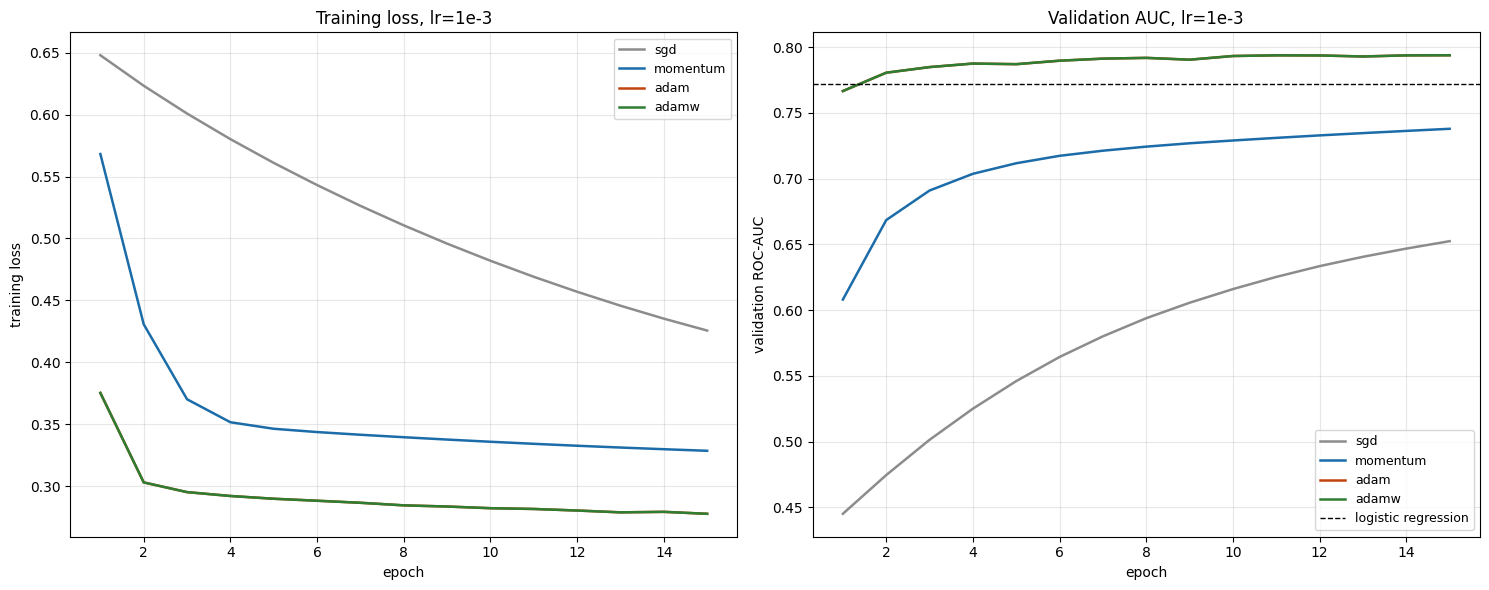

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = {"sgd": "#8c8c8c", "momentum": "#1b6ca8", "adam": "#c1440e", "adamw": "#2e7d32"}
for name, r in results.items():
    h = r["history"]
    eps = [x["epoch"] for x in h]
    axes[0].plot(eps, [x["train_loss"] for x in h], label=name, color=colors[name], lw=1.8)
    axes[1].plot(eps, [x["val_auc"] for x in h], label=name, color=colors[name], lw=1.8)

axes[1].axhline(0.7717, ls="--", c="k", lw=1, label="logistic regression")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss"); axes[0].set_title("Training loss, lr=1e-3")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation ROC-AUC"); axes[1].set_title("Validation AUC, lr=1e-3")
for a in axes: a.legend(fontsize=9); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Read the first comparison carefully.

At `lr=1e-3`, Adam and AdamW perform much better than the SGD variants in this experiment.

But it would be incorrect to conclude:

> "Adam is better than SGD."

Why?

Because the learning rate was shared.

`1e-3` is a reasonable default for Adam, but it is not necessarily a good learning rate for plain SGD on this problem.

So the experiment really asks:

> **What happens when different optimizers are forced to use the same numerical learning rate?**

That is a valid experiment, but it is not a complete optimizer comparison.

Also notice that Adam and AdamW are identical here because:

```text
AdamW + weight_decay=0
        =
Adam
```

So now we give each optimizer its own reasonable learning-rate range and compare them again.

This is a more informative comparison because each optimizer gets an opportunity to operate in a useful regime.


In [25]:
# Give each optimizer a learning rate suited to it, then compare again.
fair = {
    "sgd":      [1e-2, 1e-1, 5e-1],
    "momentum": [1e-3, 1e-2, 1e-1],
    "adamw":    [1e-4, 1e-3, 1e-2],
}
best = {}
print("sweeping each optimizer over its own plausible lr range:\n")
for name, lrs in fair.items():
    runs = []
    for lr in lrs:
        r = train(name, lr=lr, epochs=15)
        auc = r["history"][-1]["val_auc"]
        runs.append((lr, auc, r))
        print(f"  {name:9s} lr={lr:<7} final val AUC {auc:.4f}")
    lr_star, auc_star, r_star = max(runs, key=lambda t: t[1])
    best[name] = dict(lr=lr_star, auc=auc_star, run=r_star)
    print(f"  -> best for {name}: lr={lr_star}  AUC={auc_star:.4f}\n")


sweeping each optimizer over its own plausible lr range:



  sgd       lr=0.01    final val AUC 0.7386


  sgd       lr=0.1     final val AUC 0.7864


  sgd       lr=0.5     final val AUC 0.7898
  -> best for sgd: lr=0.5  AUC=0.7898



  momentum  lr=0.001   final val AUC 0.7379


  momentum  lr=0.01    final val AUC 0.7866


  momentum  lr=0.1     final val AUC 0.7966
  -> best for momentum: lr=0.1  AUC=0.7966



  adamw     lr=0.0001  final val AUC 0.7798


  adamw     lr=0.001   final val AUC 0.7939


  adamw     lr=0.01    final val AUC 0.7922
  -> best for adamw: lr=0.001  AUC=0.7939



In [26]:
print("Each optimizer at ITS OWN best learning rate:")
print(f"{'optimizer':<10} {'best lr':>9} {'final val AUC':>15} {'seconds':>9}")
print("-" * 46)
for name, b in best.items():
    print(f"{name:<10} {b['lr']:>9} {b['auc']:>15.4f} {b['run']['seconds']:>9.1f}")

spread = max(b["auc"] for b in best.values()) - min(b["auc"] for b in best.values())
print(f"\nspread between best and worst optimizer: {spread:.4f} AUC")
print(f"spread between best and worst lr for adamw alone: "
      f"{max(a for _, a, _ in [(l, train('adamw', lr=l, epochs=15)['history'][-1]['val_auc'], None) for l in [1e-4, 1e-3, 1e-2]]) - min(a for _, a, _ in [(l, train('adamw', lr=l, epochs=15)['history'][-1]['val_auc'], None) for l in [1e-4, 1e-3, 1e-2]]):.4f} AUC")


Each optimizer at ITS OWN best learning rate:
optimizer    best lr   final val AUC   seconds
----------------------------------------------
sgd              0.5          0.7898       1.0
momentum         0.1          0.7966       1.1
adamw          0.001          0.7939       1.1

spread between best and worst optimizer: 0.0068 AUC


spread between best and worst lr for adamw alone: 0.0140 AUC


Once each optimizer is given a learning rate that works reasonably well for it, the differences become much smaller.

That changes the interpretation of the first experiment.

The first plot mostly showed:

```text
optimizer + learning rate combination
```

rather than optimizer quality by itself.

The practical lesson is:

> **An optimizer cannot be evaluated independently of its hyperparameters.**

For this particular problem, AdamW's practical advantage is its **robustness to the initial learning-rate choice**. Its adaptive scaling often puts it into a useful range without as much manual tuning.

That does not mean SGD is intrinsically incapable of performing well. With a suitable learning rate, it can become competitive on this problem.

This is an important experimental-design lesson:

> **If you compare two methods, give each method a reasonable opportunity to work.**

A method that was badly tuned should not be used as evidence that the underlying method is bad.

If you ever read a paper or a blog post claiming architecture A beats architecture B, the first question is whether both were tuned with equal effort.


> **Adam/AdamW is better *by default*.** It reaches a good result without you having to find the right learning rate first, because its adaptive scaling absorbs most of the problem-specific magnitude. That robustness is worth real money in engineering time, and it is why AdamW is the 2026 default. But on a well-conditioned problem with a tuned learning rate, the gap narrows sharply.


<a id="s6"></a>
## 6. Five learning rates, five signatures

Now we keep the optimizer fixed and change only the learning rate.

This is one of the most useful experiments you can do when learning optimisation because the learning rate leaves recognizable patterns in the training curves.

We test:

```text
1e-5
1e-4
1e-3
1e-2
1e-1
0.5
```

These values differ by factors of 10, so we can see what happens when the learning rate moves from extremely small to extremely large.

The important idea is:

> **The learning rate controls how far the parameters move in response to the gradients.**

If the step is too small, learning is painfully slow.

If it is reasonable, the model learns efficiently.

If it is too large, the optimizer can overshoot good regions.

If it is extremely large, training can become unstable or the network can collapse.

The goal is to learn the visual fingerprints of these cases.

In [27]:
lr_grid = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.5]
lr_runs = {}
for lr in lr_grid:
    lr_runs[lr] = train("adamw", lr=lr, epochs=15)
    h = lr_runs[lr]["history"]
    print(f"lr={lr:<8} ep1 train {h[0]['train_loss']:.4f}  ep15 train {h[-1]['train_loss']:.4f}  "
          f"final val AUC {h[-1]['val_auc']:.4f}  best val AUC {max(x['val_auc'] for x in h):.4f}")


lr=1e-05    ep1 train 0.6555  ep15 train 0.4464  final val AUC 0.6908  best val AUC 0.6908


lr=0.0001   ep1 train 0.6026  ep15 train 0.2969  final val AUC 0.7798  best val AUC 0.7798


lr=0.001    ep1 train 0.3753  ep15 train 0.2778  final val AUC 0.7939  best val AUC 0.7939


lr=0.01     ep1 train 0.3190  ep15 train 0.2715  final val AUC 0.7922  best val AUC 0.7962


lr=0.1      ep1 train 0.3237  ep15 train 0.2939  final val AUC 0.7850  best val AUC 0.7864


lr=0.5      ep1 train 1.0491  ep15 train 0.3621  final val AUC 0.5000  best val AUC 0.5157


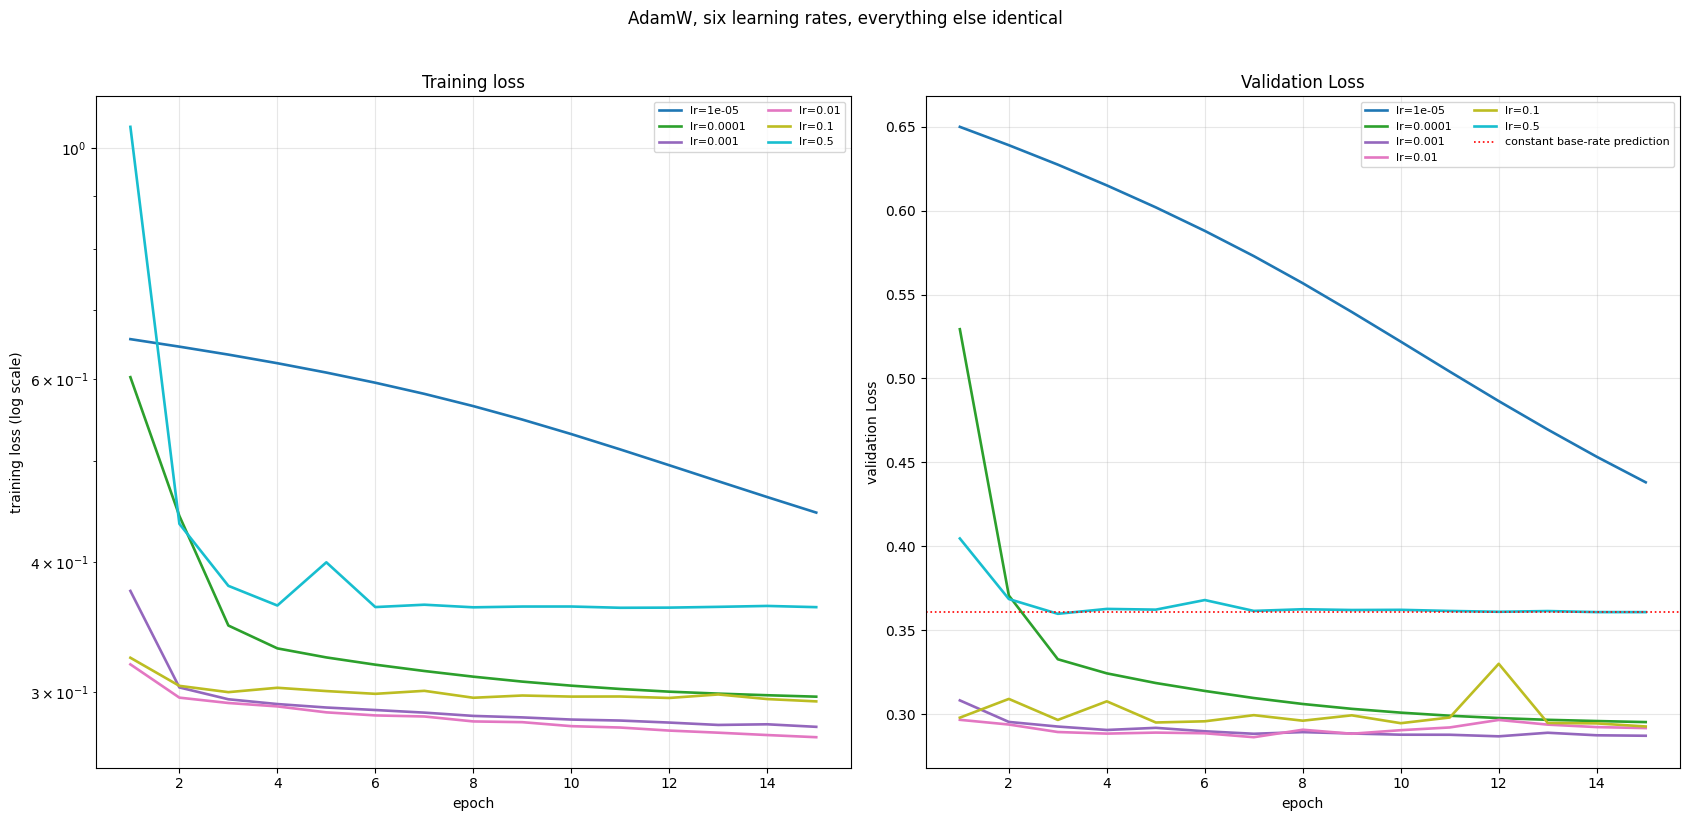

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
#cmap = plt.cm.viridis(np.linspace(0, 0.92, len(lr_grid)))
cmap  = plt.cm.tab10(np.linspace(0, 1, len(lr_grid)))
for c, lr in zip(cmap, lr_grid):
    h = lr_runs[lr]["history"]
    eps = [x["epoch"] for x in h]
    axes[0].plot(eps, [x["train_loss"] for x in h], color=c, lw=1.9, label=f"lr={lr}")
    axes[1].plot(eps, [x["val_loss"] for x in h], color=c, lw=1.9, label=f"lr={lr}")
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss (log scale)"); axes[0].set_title("Training loss")
base_rate = y_tr.mean()
axes[1].axhline(-(base_rate*np.log(base_rate) + (1-base_rate)*np.log(1-base_rate)), ls=":", c="r", lw=1.2,
                label="constant base-rate prediction")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation Loss"); axes[1].set_title("Validation Loss")
for a in axes: a.legend(fontsize=8, ncol=2); a.grid(alpha=0.3)
plt.suptitle("AdamW, six learning rates, everything else identical", y=1.02)
plt.tight_layout(); plt.show()


Here are the five learning-rate patterns.

### 1. Far too small — `lr=1e-5`

The loss decreases smoothly, but very slowly.

Nothing looks obviously broken.

That is precisely the problem: the run is wasting compute because the model has not had enough movement to reach a good solution.

**Diagnosis:** the curve is still improving substantially when training ends.

### 2. Slightly too small — `lr=1e-4`

The behaviour is similar, but the model gets further.

It is learning, but it may still need more epochs than necessary.

The difference from the previous case is mostly quantitative.

### 3. About right — `lr=1e-3`

The loss drops quickly and then flattens.

The model reaches a useful region with time left in the training run.

This is the pattern we generally want.

### 4. Slightly too large — `lr=1e-2`

The model still learns, but the curve becomes noisier.

The optimizer can move past the best region and then move back again.

A common symptom is:

```text
best validation epoch
      ↓
good performance

later epochs
      ↓
slightly worse performance
```

A learning-rate schedule can sometimes help here by reducing the step size later in training.

### 5. Far too large — `lr=0.5`

The model can enter a collapsed state.

In this experiment, the validation AUC falls to approximately `0.5`, which is the level expected from random ranking.

The important warning is:

> **A flat loss curve does not automatically mean successful convergence.**

A model can be stable because it has reached a useful minimum, or because it has become stuck in a useless solution.

Always examine a meaningful evaluation metric alongside the loss.

There is also a middle region between "works" and "completely collapses" where the model learns something but performs poorly. That region is often harder to diagnose because nothing looks catastrophically broken.


In [29]:
# The lr=0.5 run: loss looks calm, model is dead.
h_dead = lr_runs[0.5]["history"]
print("lr=0.5 — 'looks stable, is dead'")
print(f"{'epoch':>6} {'train loss':>12} {'val loss':>10} {'val AUC':>9}")
for x in h_dead:
    print(f"{x['epoch']:>6} {x['train_loss']:>12.4f} {x['val_loss']:>10.4f} {x['val_auc']:>9.4f}")

m_dead = lr_runs[0.5]["model"]
m_dead.eval()
with torch.no_grad():
    p = torch.sigmoid(m_dead(X_va)).numpy().ravel()
print(f"\npredicted probabilities: min {p.min():.6f}  max {p.max():.6f}  "
      f"std {p.std():.2e}  unique(4dp) {len(np.unique(p.round(4)))}")
print("-> the model outputs (essentially) the same number for every row.")
print(f"   base rate in the training data: {y_tr.mean():.4f}")

with torch.no_grad():
    act1 = m_dead[1](m_dead[0](X_tr[:2000]))
dead_frac = (act1.max(0).values == 0).float().mean().item()
print(f"\nfraction of layer-1 ReLU units that are dead (never fire on 2000 rows): {dead_frac:.1%}")
print("-> Note 3.3 explains why a too-large step kills ReLU units permanently.")


lr=0.5 — 'looks stable, is dead'
 epoch   train loss   val loss   val AUC
     1       1.0491     0.4047    0.5099
     2       0.4355     0.3687    0.4980
     3       0.3796     0.3599    0.5157
     4       0.3634     0.3628    0.5148
     5       0.3999     0.3624    0.5000
     6       0.3621     0.3681    0.5000
     7       0.3640     0.3616    0.5000
     8       0.3619     0.3626    0.5000
     9       0.3626     0.3622    0.5002
    10       0.3626     0.3623    0.5000
    11       0.3616     0.3616    0.5000
    12       0.3617     0.3611    0.5000
    13       0.3623     0.3615    0.5000
    14       0.3630     0.3609    0.5000
    15       0.3621     0.3609    0.5000

predicted probabilities: min 0.116210  max 0.116210  std 7.45e-09  unique(4dp) 1
-> the model outputs (essentially) the same number for every row.
   base rate in the training data: 0.1170

fraction of layer-1 ReLU units that are dead (never fire on 2000 rows): 95.3%
-> Note 3.3 explains why a too-large step 

The `lr=0.5` model has effectively learned the simplest possible prediction: the **base rate**.

The base rate is the proportion of positive examples in the training data.

If approximately 11.7% of training examples are positive, the model can minimise its binary cross-entropy loss surprisingly well by predicting approximately `0.117` for every example.

That gives:

```text
example 1 → 0.117
example 2 → 0.117
example 3 → 0.117
...
```

The model is no longer using the input features to distinguish examples.

This explains the combination:

```text
stable loss
+
AUC ≈ 0.5
+
almost identical predictions
=
model collapse to a constant prediction
```

This is a valuable diagnostic pattern that will appear again later in the curriculum.

The broader lesson is:

> **Never interpret a training curve using loss alone. Always check whether the model is actually making useful, varying predictions.**


### Check your understanding

Suppose the loss is steadily falling from `0.69` to `0.42` after 50 epochs and is still falling.

Two possible explanations are:

```text
1. learning rate is too small
2. learning rate is fine, but more epochs are needed
```

The key question is not simply whether the loss is still decreasing.

Ask:

> **How quickly is it decreasing, and what is happening to the validation metric?**

If the curve is still improving meaningfully and smoothly, more epochs may be enough.

If the loss is decreasing extremely slowly from the beginning, increasing the learning rate may make training more efficient.

So the decision should be based on the **shape of the curve and the validation behaviour**, not on the final loss value alone.

<a id="s7"></a>
## 7. Finding a learning rate in one run

In the previous section, we tried several learning rates separately.

That is called a **learning-rate sweep** or grid search.

It works, but it requires multiple training runs.

For a small example, that is cheap.

For a large model, one complete training run could take hours or days.

The **LR range test** tries to get useful information from a single run.

### The idea

Start with an extremely small learning rate.

Then increase it after every batch:

```text
very small
   ↓
small
   ↓
useful
   ↓
too large
   ↓
unstable
```

While doing this, record the loss.

The resulting curve gives us a picture of how the model reacts as the learning rate changes.

Typical pattern:

```text
learning rate very small
→ loss barely changes

learning rate enters useful range
→ loss falls quickly

learning rate becomes too large
→ loss stops improving and eventually rises
```

The test is therefore not another training strategy. It is a **diagnostic experiment for choosing a starting learning-rate range**.

In [30]:
def lr_range_test(lr_min=1e-7, lr_max=10.0, n_steps=300, batch_size=256, seed=SEED, beta=0.92):
    """Exponentially ramp the lr over n_steps batches; record smoothed loss."""
    model = make_model(seed=seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr_min)
    g = torch.Generator().manual_seed(seed)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr),
        batch_size=batch_size, shuffle=True, generator=g)

    gamma = (lr_max / lr_min) ** (1 / n_steps)
    lrs, raw, smooth = [], [], []
    avg = 0.0
    step = 0
    model.train()
    while step < n_steps:
        for xb, yb in loader:
            if step >= n_steps: break
            for grp in opt.param_groups:
                grp["lr"] = lr_min * (gamma ** step)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

            l = loss.item()
            avg = beta * avg + (1 - beta) * l                 # exponential smoothing
            lrs.append(opt.param_groups[0]["lr"])
            raw.append(l)
            smooth.append(avg / (1 - beta ** (step + 1)))     # bias correction
            step += 1
    return np.array(lrs), np.array(smooth), np.array(raw)

lrs, smooth, raw = lr_range_test()
print(f"ran {len(lrs)} batches, lr from {lrs[0]:.1e} to {lrs[-1]:.1e}")
print(f"minimum smoothed loss {smooth.min():.4f} at lr={lrs[int(np.argmin(smooth))]:.2e}")


ran 300 batches, lr from 1.0e-07 to 9.4e+00
minimum smoothed loss 0.3046 at lr=1.45e-01


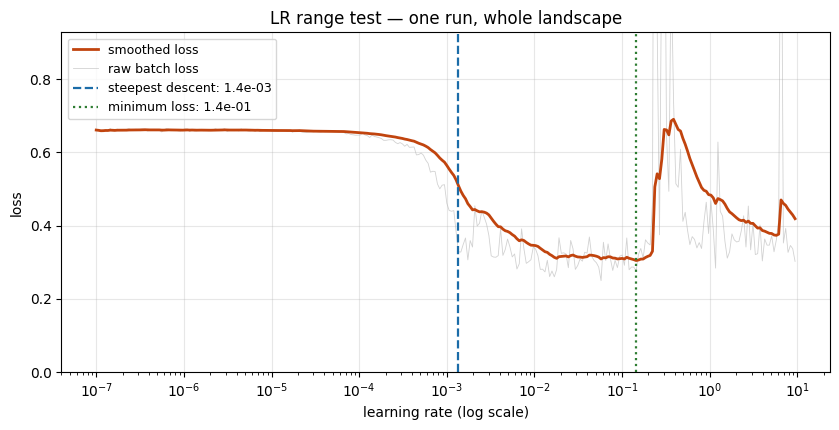

steepest-descent lr : 1.36e-03
minimum-loss lr     : 1.45e-01
rule of thumb (min-loss / 10): 1.45e-02

Section 6's grid search said the best lr was around 1e-3 to 1e-2.


In [31]:
# Steepest-descent point: where the smoothed loss is falling fastest (in log-lr).
grad_ = np.gradient(smooth, np.log10(lrs))
i_min = int(np.argmin(smooth))
lr_min_loss = lrs[i_min]
# The steepest-descent point must be searched BEFORE the loss minimum.
# Searching the whole curve finds the post-minimum blow-up instead.
lr_steep = lrs[int(np.argmin(grad_[:i_min]))] if i_min > 1 else lr_min_loss

plt.figure(figsize=(8.5, 4.4))
plt.plot(lrs, smooth, lw=2, color="#c1440e", label="smoothed loss")
plt.plot(lrs, raw, lw=0.6, color="0.75", alpha=0.7, zorder=0, label="raw batch loss")
plt.axvline(lr_steep, ls="--", c="#1b6ca8", lw=1.6, label=f"steepest descent: {lr_steep:.1e}")
plt.axvline(lr_min_loss, ls=":", c="#2e7d32", lw=1.6, label=f"minimum loss: {lr_min_loss:.1e}")
plt.xscale("log"); plt.xlabel("learning rate (log scale)"); plt.ylabel("loss")
plt.title("LR range test — one run, whole landscape")
plt.ylim(0, min(1.2, float(np.nanpercentile(smooth, 99)) * 1.4))
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"steepest-descent lr : {lr_steep:.2e}")
print(f"minimum-loss lr     : {lr_min_loss:.2e}")
print(f"rule of thumb (min-loss / 10): {lr_min_loss/10:.2e}")
print(f"\nSection 6's grid search said the best lr was around 1e-3 to 1e-2.")


The usual idea is to choose a learning rate somewhat below the point where the range test reaches its minimum loss.

A common heuristic is:

```text
recommended lr ≈ minimum-loss lr / 10
```

The reason is that the minimum of the short range-test curve may already be close to the point where training becomes unstable. Choosing a somewhat smaller value provides a safety margin for a full training run.

### One important implementation detail

The code searches for the steepest decrease **before** the loss minimum.

Why?

After the minimum, the loss starts increasing.

The steepest part of that increase can produce a large gradient too, but it is pointing in the wrong direction for our purpose. A naive search over the entire curve could therefore identify the instability region instead of the useful region.

### Do not treat the range test as an oracle

The LR range test tells us about learning-rate behaviour during this particular short experiment.

It does not guarantee the perfect learning rate for the full training run.

The weights are changing throughout the test, and the learning rate itself is changing every batch.

So the loss at a particular learning rate is **not equivalent to running a complete training job at that learning rate**.

Instead, use the curve to answer:

> **"What range of learning rates appears promising?"**

Then confirm that range with a normal training run.

A second limitation is smoothing. The raw batch loss is noisy, so the test smooths it. Too little smoothing leaves the curve noisy; too much smoothing can move the apparent transition point.

Treat the result as a starting point, not a final answer.

<a id="s8"></a>
## 8. Learning-rate schedules

A learning-rate schedule changes the learning rate during training.

Why would we want that?

Early in training, the model is usually far from a useful solution. Larger steps can help it move through parameter space quickly.

Later, once it is near a good solution, smaller steps can help it settle rather than repeatedly jumping around.

So the basic idea is:

```text
early training
→ larger learning rate
→ cover ground quickly

later training
→ smaller learning rate
→ make finer adjustments
```

This is called **learning-rate decay** or a **learning-rate schedule**.

Three common patterns are:

### Step decay

Multiply the learning rate by a fixed factor every few epochs.

Example:

```text
start: 0.01
epoch 5: 0.001
epoch 10: 0.0001
```

It is simple and easy to inspect.

### Cosine annealing

Reduce the learning rate smoothly according to a cosine-shaped curve.

Instead of sudden jumps, the learning rate gradually decreases.

### Warmup followed by decay

Start with a very small learning rate, gradually increase it for the first part of training, and then reduce it.

Warmup is particularly common in Transformer training, where large early updates can destabilise a freshly initialised model.

We test schedules starting from `lr=1e-2`, which the previous experiment identified as somewhat too large for a constant learning rate.

In [32]:
sched_runs = {}
for tag, kw in [("constant",     dict(scheduler=None)),
                ("step  x0.1/5", dict(scheduler="step")),
                ("cosine",       dict(scheduler="cosine"))]:
    r = train("adamw", lr=1e-2, epochs=15, **kw)
    sched_runs[tag] = r
    h = r["history"]
    print(f"{tag:14s} final val loss {h[-1]['val_loss']:.4f}   "
          f"final val AUC {h[-1]['val_auc']:.4f}   best val AUC {max(x['val_auc'] for x in h):.4f}")


constant       final val loss 0.2919   final val AUC 0.7922   best val AUC 0.7962


step  x0.1/5   final val loss 0.2855   final val AUC 0.7970   best val AUC 0.7976


cosine         final val loss 0.2882   final val AUC 0.7960   best val AUC 0.7968


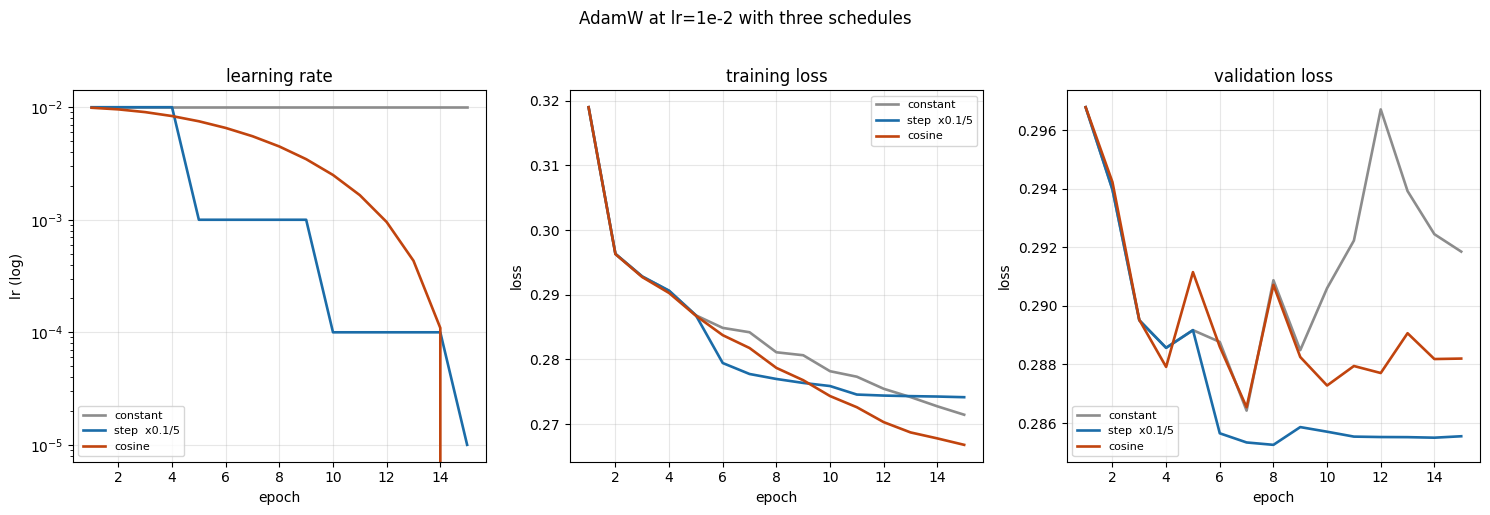

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.0))
cols = {"constant": "#8c8c8c", "step  x0.1/5": "#1b6ca8", "cosine": "#c1440e"}
for tag, r in sched_runs.items():
    h = r["history"]; eps = [x["epoch"] for x in h]
    axes[0].plot(eps, [x["lr"] for x in h], lw=1.9, color=cols[tag], label=tag)
    axes[1].plot(eps, [x["train_loss"] for x in h], lw=1.9, color=cols[tag], label=tag)
    axes[2].plot(eps, [x["val_loss"] for x in h], lw=1.9, color=cols[tag], label=tag)
axes[0].set_yscale("log"); axes[0].set_title("learning rate"); axes[0].set_ylabel("lr (log)")
axes[1].set_title("training loss"); axes[1].set_ylabel("loss")
axes[2].set_title("validation loss"); axes[2].set_ylabel("loss")
for a in axes: a.set_xlabel("epoch"); a.legend(fontsize=8); a.grid(alpha=0.3)
plt.suptitle("AdamW at lr=1e-2 with three schedules", y=1.02)
plt.tight_layout(); plt.show()


Read the schedule experiment in two stages.

### First: inspect the learning-rate curve

The learning-rate panel tells us whether the scheduler actually performed the requested changes.

For example:

```text
step decay
→ sudden drops

cosine
→ smooth decrease
```

### Second: inspect the validation performance

The important distinction is between:

- **final performance** — performance at the last epoch;
- **best performance** — the best validation score reached at any epoch.

A schedule can improve the final epoch without improving the best epoch.

That can happen when a constant learning rate reaches a good region but keeps bouncing around it. A schedule reduces the learning rate, so the model settles there.

Whether that matters depends on how your training pipeline chooses the model to keep.

If you save the **best validation checkpoint**, the schedule may add little value in this particular short experiment.

If your pipeline always uses the **final checkpoint**, reducing the learning rate can make a meaningful difference.

### When schedules become more valuable

Schedules tend to become more useful when:

- training runs for many epochs;
- you must use the final checkpoint;
- the model benefits from warmup, as in many Transformer setups;
- training is expensive enough that unstable late-stage updates waste significant compute.

The general engineering lesson is:

> **Do not add a technique simply because it exists. Add it when the problem you have actually requires it.**

<a id="s9"></a>
## 9. What actually moved the needle

Let's assemble everything into one table and draw the conclusions that survive scrutiny.

The purpose of the table is not to produce a universal ranking of optimizers.

It is to answer a narrower question:

> **On this dataset, architecture, preprocessing pipeline, batch size, seed, and training budget, how much did each optimization decision change the final validation AUC?**

Remember that these are measurements from this particular experimental setup.

Small differences should not be treated as universal truths, especially because these experiments use a single seed.

In [34]:
rows = []
rows.append(("Day 2 reference (Adam 1e-3, 15 ep)", results["adam"]["history"][-1]["val_auc"]))
rows.append(("logistic regression baseline", 0.7717))
rows.append(("majority-class (AUC by definition)", 0.5000))
rows.append(("--- optimizer, shared lr=1e-3 ---", None))
for n in ["sgd", "momentum", "adam", "adamw"]:
    rows.append((f"  {n}", results[n]["history"][-1]["val_auc"]))
rows.append(("--- optimizer, each at its own best lr ---", None))
for n, b in best.items():
    rows.append((f"  {n} (lr={b['lr']})", b["auc"]))
rows.append(("--- learning rate, AdamW ---", None))
for lr in lr_grid:
    rows.append((f"  lr={lr}", lr_runs[lr]["history"][-1]["val_auc"]))
rows.append(("--- schedule, AdamW lr=1e-2 ---", None))
for tag, r in sched_runs.items():
    rows.append((f"  {tag}", r["history"][-1]["val_auc"]))

print(f"{'configuration':<44}{'final val AUC':>14}")
print("=" * 58)
for name, v in rows:
    print(f"{name:<44}{'':>14}" if v is None else f"{name:<44}{v:>14.4f}")


configuration                                final val AUC
Day 2 reference (Adam 1e-3, 15 ep)                  0.7939
logistic regression baseline                        0.7717
majority-class (AUC by definition)                  0.5000
--- optimizer, shared lr=1e-3 ---                         
  sgd                                               0.6525
  momentum                                          0.7379
  adam                                              0.7939
  adamw                                             0.7939
--- optimizer, each at its own best lr ---                
  sgd (lr=0.5)                                      0.7898
  momentum (lr=0.1)                                 0.7966
  adamw (lr=0.001)                                  0.7939
--- learning rate, AdamW ---                              
  lr=1e-05                                          0.6908
  lr=0.0001                                         0.7798
  lr=0.001                                          0.79

In [35]:
# Which choice had the largest effect?
opt_spread   = max(b["auc"] for b in best.values()) - min(b["auc"] for b in best.values())
opt_spread_f = max(results[n]["history"][-1]["val_auc"] for n in results) - \
               min(results[n]["history"][-1]["val_auc"] for n in results)
lr_spread    = max(lr_runs[l]["history"][-1]["val_auc"] for l in lr_grid) - \
               min(lr_runs[l]["history"][-1]["val_auc"] for l in lr_grid)
sch_spread   = max(r["history"][-1]["val_auc"] for r in sched_runs.values()) - \
               min(r["history"][-1]["val_auc"] for r in sched_runs.values())

print("Effect size of each decision (range of final val AUC):")
print(f"  choice of learning rate (AdamW, {min(lr_grid):.0e}..{max(lr_grid):g})   {lr_spread:.4f}")
print(f"  choice of optimizer at a SHARED lr=1e-3        {opt_spread_f:.4f}")
print(f"  choice of optimizer, each optimally tuned      {opt_spread:.4f}")
print(f"  choice of schedule                             {sch_spread:.4f}")


Effect size of each decision (range of final val AUC):
  choice of learning rate (AdamW, 1e-05..0.5)   0.2939
  choice of optimizer at a SHARED lr=1e-3        0.1414
  choice of optimizer, each optimally tuned      0.0068
  choice of schedule                             0.0048


### What to take away

**1. Learning rate has a large effect**

Across the tested range, changing the learning rate produced large changes in validation performance.

This makes learning rate one of the first things to investigate when a training run behaves badly.

**2. Optimizer choice and learning rate are connected**

At one shared learning rate, the optimizers looked very different.

When each optimizer was given a learning rate suited to it, the gap became much smaller.

So do not ask only:

> "Which optimizer is best?"

Ask:

> "Which optimizer and learning-rate combination works well for this problem?"

For this curriculum, AdamW is the practical default because its adaptive updates often make it easier to get into a useful regime without extensive learning-rate tuning.

**3. Schedules are usually a refinement**

The schedule experiments show how reducing the learning rate later can help a model settle.

But the benefit in this short experiment is relatively small.

That does not make schedules useless. It means their value depends on the training setup.

**4. AdamW separates weight decay**

AdamW combines Adam-style adaptive updates with decoupled weight decay.

If:

```python
weight_decay=0
```

then AdamW behaves like Adam.

If weight decay is non-zero, AdamW applies that shrinkage separately from the adaptive gradient calculation.

**5. A flat loss does not prove successful convergence**

The `lr=0.5` experiment is the important warning.

The loss becomes stable, but the model has collapsed to almost the same prediction for every example and the AUC is around chance level.

So:

> **Always interpret the loss together with a meaningful evaluation metric and, when useful, inspect the predictions themselves.**

**One limitation of this notebook**

Most experiments here use a single seed.

If two configurations differ by only a very small amount of AUC, that difference may be caused by randomness rather than a real advantage.

Note 3.2 will examine this issue more carefully.

So for now, treat small gaps as tentative rather than established.

### Transition to Note 3.2

You can now make a network learn efficiently.

The next question is different:

> **What prevents the model from learning the training data too specifically?**

That is the subject of regularisation and generalisation.

Bank Marketing is not ideal for demonstrating severe overfitting because the training set is large relative to this small network.

Note 3.2 therefore moves to a smaller dataset where the model can memorise the training examples much more easily, making dropout, weight decay, and early stopping easier to observe.